In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import yfinance as yf
import pandas as pd
import seaborn as sns
import seaborn.objects as so
from keras import Input
from keras import layers, Model
import tensorflow as tf
from tensorflow.keras.optimizers import RMSprop, Adam, SGD
import random
import sys
sys.path.append('../..')
#import ep.etools as apt
# import warnings
# warnings.filterwarnings( "ignore", module = "matplotlib\..*" )
from tqdm import tqdm
from pandas.tseries.offsets import DateOffset,BusinessDay

,Day-ahead,Month-ahead,Quarter-ahead,Summer 24,Winter 24,Year-Ahead,2 Year-Ahead
date_m,,,,,,,
2010-01-01,14.30,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,16.25,13.70,NaN,NaN,NaN,NaN,NaN
2010-01-05,14.15,13.96,NaN,NaN,NaN,NaN,NaN
2010-01-06,14.65,13.80,NaN,NaN,NaN,NaN,NaN
2010-01-07,16.18,13.82,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2024-03-08,26.34,26.39,26.51,NaN,NaN,30.19,28.67
2024-03-11,25.02,24.97,25.10,25.33,29.56,29.19,27.78
2024-03-12,25.01,24.82,24.94,25.18,29.24,28.82,27.46


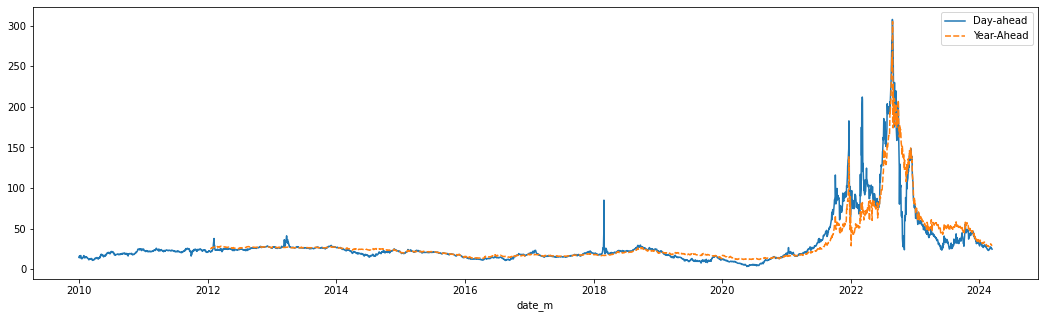

In [2]:
# dataCalendar = pd.read_csv('./data/bloc_ttf_calendar_prices.csv')
dataPrices = pd.read_csv('./data/bloc_ttf_prices.csv')
dataPrices['date_m'] = pd.to_datetime(dataPrices['date_m'])
dataPrices = dataPrices.set_index('date_m')
fig, ax = plt.subplots(figsize=(18,5))
# sns.set_palette("mako")
sns.lineplot(dataPrices[['Day-ahead','Year-Ahead']][0:-1], color='Blue'); #3390
#ax2 = plt.twinx()
#sns.lineplot(data=final['€/$'], ax=ax2 , color='grey')
dataPrices

# Lecture des informations de stock de Gaz depuis AGSI
* normalisation des données
* conversion en float
* conversion des dates

pour un Pays remplacer "type" par "country" et mettre en paramètre le code du pays : FR, BE, DE ...

In [257]:
import requests
params = {
    "type": "EU",
    "from": "2010-01-01",
    "size": 10000
}
header = {
  "x-key" : "99e18f932d22c9acf9c42f27d0b8b539" }

url = "https://agsi.gie.eu/api"
resp = requests.get(url=url, params=params, headers=header)
json = resp.json()
data = pd.json_normalize(json['data'])
data["gasInStorage"] = data["gasInStorage"].astype(float)
data["full"] = data["full"].astype(float)
#data["coveredCapacity"] = data["coveredCapacity"].astype(float)
data['date'] =pd.to_datetime(data['gasDayStart'], errors='coerce')
data = data.set_index(data['date'])
#data[["gasDayStart","gasInStorage"]]
#print(data)
print('Done')

Done


In [258]:
data

,name,code,url,updatedAt,gasDayStart,gasInStorage,consumption,consumptionFull,injection,withdrawal,...,injectionCapacity,withdrawalCapacity,contractedCapacity,availableCapacity,coveredCapacity,status,trend,full,info,date
date,,,,,,,,,,,,,,,,,,,,,
2024-03-31,EU,eu,eu,2024-04-01 19:02:11,2024-03-31,670.0945,3760.87,17.82,2865.91,873.6,...,11648.77,19898.51,-,-,100,E,-0.01,58.72,[],2024-03-31
2024-03-30,EU,eu,eu,2024-04-01 19:01:05,2024-03-30,670.2626,3760.87,17.82,1398.33,938.8,...,11468.13,19628.07,-,-,100,E,0.04,58.81,[],2024-03-30
2024-03-29,EU,eu,eu,2024-04-01 19:01:20,2024-03-29,669.8098,3760.87,17.81,1168.08,1233.9,...,11665.31,19923.38,-,-,100,E,-0.01,58.69,[],2024-03-29
2024-03-28,EU,eu,eu,2024-04-01 19:01:35,2024-03-28,669.9016,3760.87,17.81,717.46,1938.3,...,11665.23,19927.05,-,-,100,E,-0.11,58.70,[],2024-03-28
2024-03-27,EU,eu,eu,2024-04-01 19:01:54,2024-03-27,671.1521,3760.87,17.85,704.42,1803.2,...,11665.17,19923.74,-,-,100,E,-0.1,58.81,[],2024-03-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-01-05,EU,eu,eu,2023-04-18 10:46:51,2011-01-05,428.0276,3530,12.13,62.45,3640.9,...,5392.47,10316.05,-,-,-,C,-0.58,69.32,[],2011-01-05
2011-01-04,EU,eu,eu,2023-04-18 10:46:51,2011-01-04,431.5952,3530,12.23,44.25,3829.5,...,5392.62,10316.06,-,-,-,C,-0.6,69.89,[],2011-01-04
2011-01-03,EU,eu,eu,2023-04-18 10:46:51,2011-01-03,435.3212,3530,12.33,110.6,3323.2,...,5392.74,10316.04,-,-,-,C,-0.51,70.50,[],2011-01-03


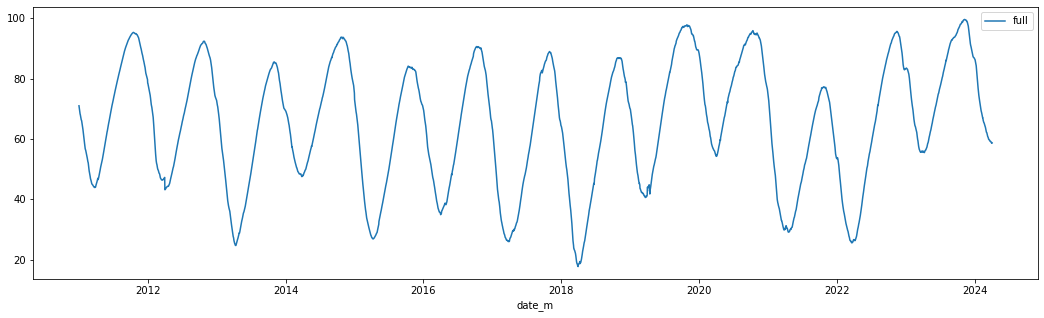

In [260]:
data['date_m'] = pd.to_datetime(data['gasDayStart'])
data = data.set_index('date_m')
fig, ax = plt.subplots(figsize=(18,5))
# sns.set_palette("mako")
sns.lineplot(data[['full']][0:-1], color='Blue'); #3390

# Détermination du caractère Stationnaire de l'évolution du stockage de Gaz ...

In [261]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error

In [262]:
def adf_test(serie):
    adf = adfuller(serie,autolag='AIC')
    print('Test Dickey Fuller')
    print('Test adf',adf[0])
    print('p-Value',adf[1],' Mac Kinnon')
    print('used Lags',adf[2])
    print('Number of obs',adf[3])
    for k,v in adf[4].items():
        print('critical value',k,'->',v)
    print('max Info',adf[5])    

In [263]:
def kpss_test(serie):
    kpss_ = kpss(serie,regression="c", nlags="auto")
    print('Test KPSS')
    print('Test kpss',kpss_[0])
    print('p-Value',kpss_[1])
    print('used Lags',kpss_[2])
    for k,v in kpss_[3].items():
        print('critical value',k,'->',v)

In [264]:
data.dropna()
adf_test(data['full'])


Test Dickey Fuller
Test adf -9.621861030245116
p-Value 1.7006354864328085e-16  Mac Kinnon
used Lags 30
Number of obs 4808
critical value 1% -> -3.431710814205638
critical value 5% -> -2.8621413274433674
critical value 10% -> -2.5670900882351515
max Info -5434.86528038671


In [265]:
kpss_test(data['full'])

Test KPSS
Test kpss 0.20495175393835163
p-Value 0.1
used Lags 42
critical value 10% -> 0.347
critical value 5% -> 0.463
critical value 2.5% -> 0.574
critical value 1% -> 0.739


/var/folders/vw/2g_98rts7tzczmvh5hqt_qn00000gn/T/ipykernel_87531/2657295217.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_ = kpss(serie,regression="c", nlags="auto")


Test Dickey Fuller
Test adf -2.331238172490048
p-Value 0.1620908446940354  Mac Kinnon
used Lags 5
Number of obs 699
critical value 1% -> -3.439739809554328
critical value 5% -> -2.86568368980381
critical value 10% -> -2.5689766074363334
max Info 4979.920656264398
Test KPSS
Test kpss 1.264318530673321
p-Value 0.01
used Lags 17
critical value 10% -> 0.347
critical value 5% -> 0.463
critical value 2.5% -> 0.574
critical value 1% -> 0.739


/var/folders/vw/2g_98rts7tzczmvh5hqt_qn00000gn/T/ipykernel_87531/2657295217.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_ = kpss(serie,regression="c", nlags="auto")


date_m
2021-07-02    36.30
2021-07-05    37.72
2021-07-06    33.99
2021-07-07    32.71
2021-07-08    34.02
              ...  
2024-03-08    26.34
2024-03-11    25.02
2024-03-12    25.01
2024-03-13    24.54
2024-03-14    25.34
Name: Day-ahead, Length: 705, dtype: float64

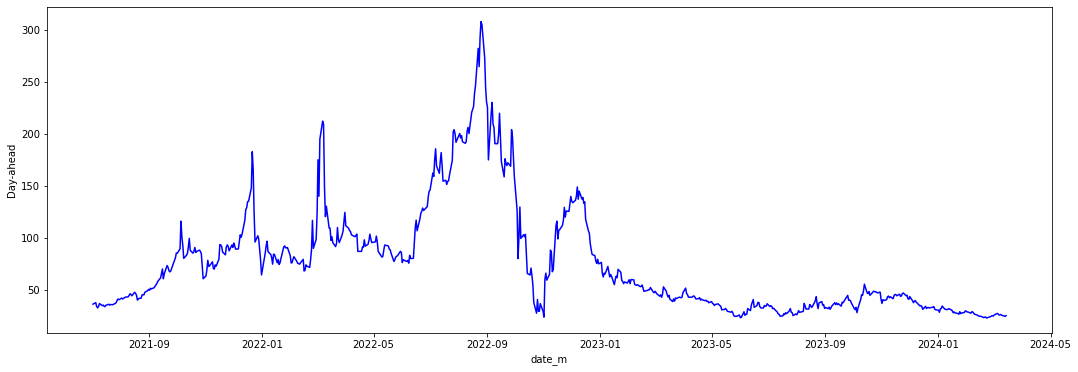

In [266]:
fig = plt.figure(figsize=(18,6))
sns.lineplot(data=dataPrices['Day-ahead'][3000:].dropna(),color='Blue')
adf_test(dataPrices['Day-ahead'][3000:].dropna())
kpss_test(dataPrices['Day-ahead'][3000:])
dataPrices['Day-ahead'][3000:]

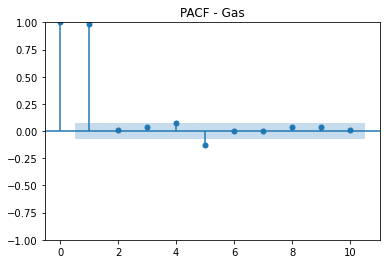

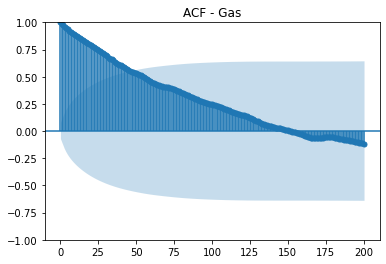

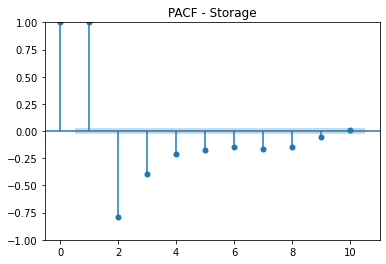

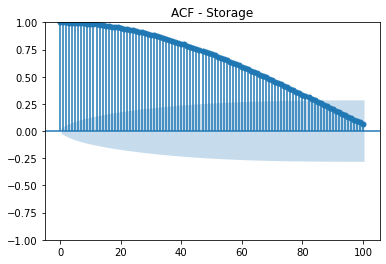

In [267]:
plot_pacf(dataPrices['Month-ahead'][3000:].dropna(),lags=10,title='PACF - Gas')
plot_acf(dataPrices['Month-ahead'][3000:].dropna(),lags=200,title='ACF - Gas')
plot_pacf(data['full'],lags=10,title='PACF - Storage')
plot_acf(data['full'],lags=100,title='ACF - Storage')
plt.show()

# Prévision de l'avolution du stockage

In [300]:
model=AutoReg(dataPrices['Day-ahead'][:],lags=120).fit()
model.summary()

/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:              Day-ahead   No. Observations:                 3705
Model:                   AutoReg(120)   Log Likelihood               -9972.813
Method:               Conditional MLE   S.D. of innovations              3.907
Date:                Mon, 01 Apr 2024   AIC                          20189.625
Time:                        23:14:55   BIC                          20944.136
Sample:                    06-18-2010   HQIC                         20458.573
                         - 03-14-2024                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1715      0.095      1.803      0.071      -0.015       0.358
Day-ahead.L1       1.0190      0.017     61.098      0.000       0.986       1.052
Day-ahead.L2      -0.1027      0.024     -4.313      0.000      -0.149      -0.056
Day-ahead.L3       0.0505      0.024      2.118      0.034       0.004       0.097
Day-ahead.L4       0.1379      0.024      5.794      0.000       0.091       0.185
Day-ahead.L5      -0.1660      0.024     -6.952      0.000      -0.213      -0.119
Day-ahead.L6       0.0042      0.024      0.174      0.862      -0.043       0.051
Day-ahead.L7       0.0687      0.024      2.859      0.004       0.022       0.116
Day-ahead.L8      -0.0250      0.024     -1.040      0.298      -0.072       0.022
Day-ahead.L9       0.0092      0.024      0.381      0.703      -0.038       0.056
Day-ahead.L10     -0.0237      0.024     -0.985      0.324      -0.071       0.023
Day-ahead.L11      0.0708      0.024      2.943      0.003       0.024       0.118
Day-ahead.L12     -0.0908      0.024     -3.775      0.000      -0.138      -0.044
Day-ahead.L13      0.0589      0.024      2.448      0.014       0.012       0.106
Day-ahead.L14     -0.0248      0.024     -1.030      0.303      -0.072       0.022
Day-ahead.L15      0.0338      0.024      1.406      0.160      -0.013       0.081
Day-ahead.L16      0.0336      0.024      1.395      0.163      -0.014       0.081
Day-ahead.L17     -0.0775      0.024     -3.226      0.001      -0.125      -0.030
Day-ahead.L18     -0.0370      0.024     -1.539      0.124      -0.084       0.010
Day-ahead.L19      0.0936      0.024      3.893      0.000       0.046       0.141
Day-ahead.L20     -0.0623      0.024     -2.588      0.010      -0.109      -0.015
Day-ahead.L21     -0.0338      0.024     -1.402      0.161      -0.081       0.013
Day-ahead.L22      0.0909      0.024      3.773      0.000       0.044       0.138
Day-ahead.L23     -0.0032      0.024     -0.132      0.895      -0.050       0.044
Day-ahead.L24     -0.0296      0.024     -1.228      0.220      -0.077       0.018
Day-ahead.L25      0.0935      0.024      3.876      0.000       0.046       0.141
Day-ahead.L26     -0.1343      0.024     -5.560      0.000      -0.182      -0.087
Day-ahead.L27      0.0194      0.024      0.802      0.423      -0.028       0.067
Day-ahead.L28     -0.0252      0.024     -1.040      0.298      -0.073       0.022
Day-ahead.L29     -0.0178      0.024     -0.734      0.463      -0.065       0.030
Day-ahead.L30      0.0938      0.024      3.868      0.000       0.046       0.141
Day-ahead.L31     -0.0737      0.024     -3.034      0.002      -0.121      -0.026
Day-ahead.L32     -0.0119      0.024     -0.490      0.624      -0.060       0.036
Day-ahead.L33      0.0747      0.024      3.073      0.002       0.027       0.122
Day-ahead.L34     -0.0578      0.024     -2.376      0.017      -0.106      -0.010
Day-ahead.L35      0.0518      0.024      2.127      0.033       0.004       0.100
Day-

RMSE 2.0484675754312356


/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/tsa/deterministic.py:302: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


<AxesSubplot:xlabel='date_m', ylabel='Day-ahead'>

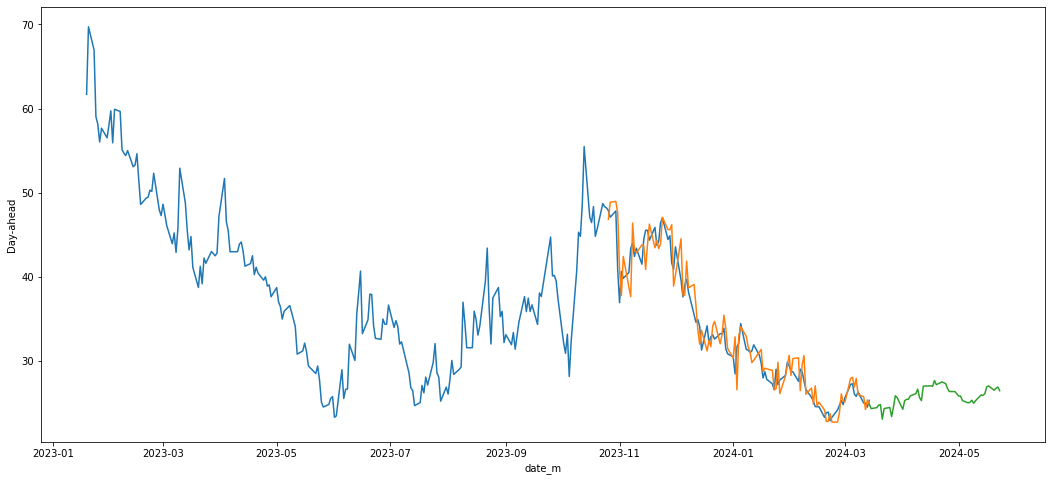

In [301]:
vmin= 3604
vmax=3704
control = model.predict(start=vmin,end=vmax,dynamic=False)
futur = model.predict(start=vmax,end=(vmax+50),dynamic=False)
rmse = math.sqrt(mean_squared_error(dataPrices['Day-ahead'][vmin:(vmax+1)],control))
print('RMSE',rmse)
fig = plt.figure(figsize=(18,8))
sns.lineplot(dataPrices['Day-ahead'][(vmin-200):])
sns.lineplot(control)
sns.lineplot(futur)

# ARIMA model

In [ ]:
#!pip install pmdarima

In [270]:
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

In [282]:
# all = dataPrices['Day-ahead'].dropna()
all = data['full'][::-1].dropna()
train = all.iloc[:-30]
test = all.iloc[-30:]
step = auto_arima(all,trace=True,suppress_warnings=True)
step.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-4848.636, Time=1.38 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3968.934, Time=0.21 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-3776.603, Time=0.16 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=720.545, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3967.181, Time=0.10 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-4890.763, Time=1.22 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-1171.045, Time=0.52 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-4852.340, Time=1.00 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-4940.025, Time=1.25 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-1987.336, Time=0.83 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-4920.907, Time=2.29 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=-4943.134, Time=2.51 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=-2743.470, Time=1.04 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=-4943.655, Time=3.36 sec
 ARIMA(3,1,4)(0,0,0)[0]

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 4839
Model:               SARIMAX(5, 1, 5)   Log Likelihood                2712.734
Date:                Mon, 01 Apr 2024   AIC                          -5401.468
Time:                        23:08:02   BIC                          -5323.657
Sample:                    01-01-2011   HQIC                         -5374.151
                         - 03-31-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0002      0.002     -0.081      0.936      -0.005       0.004
ar.L1          0.5208      0.026     19.672      0.000       0.469       0.573
ar.L2          0.6965      0.040     17.381      0.000       0.618       0.775
ar.L3         -0.7764      0.035    -22.268      0.000      -0.845      -0.708
ar.L4         -0.3737      0.040     -9.338      0.000      -0.452      -0.295
ar.L5          0.9317      0.026     35.210      0.000       0.880       0.984
ma.L1         -0.1611      0.027     -6.032      0.000      -0.213      -0.109
ma.L2         -0.4963      0.032    -15.386      0.000      -0.559      -0.433
ma.L3          0.6730      0.031     21.863      0.000       0.613       0.733
ma.L4          0.5412      0.038     14.394      0.000       0.468       0.615
ma.L5         -0.5601      0.021    -26.711      0.000      -0.601      -0.519
sigma2         0.0189      4e-05    471.669      0.000       0.019       0.019
===================================================================================
Ljung-Box (L1) (Q):                   0.33   Jarque-Bera (JB):          10449601.47
Prob(Q):                              0.57   Prob(JB):                         0.00
Heteroskedasticity (H):               0.48   Skew:                            -4.89
Prob(H) (two-sided):                  0.00   Kurtosis:                       230.47
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [286]:
all.describe()

count    4839.000000
mean       65.092017
std        20.663853
min        17.700000
25%        48.795000
50%        66.990000
75%        83.140000
max        99.630000
Name: full, dtype: float64

/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   full   No. Observations:                 4809
Model:                 ARIMA(5, 1, 5)   Log Likelihood                2688.174
Date:                Mon, 01 Apr 2024   AIC                          -5354.348
Time:                        23:08:21   BIC                          -5283.090
Sample:                    01-01-2011   HQIC                         -5329.324
                         - 03-01-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5123      0.033     15.328      0.000       0.447       0.578
ar.L2          0.7148      0.050     14.269      0.000       0.617       0.813
ar.L3         -0.7943      0.042    -18.805      0.000      -0.877      -0.711
ar.L4         -0.3662      0.050     -7.326      0.000      -0.464      -0.268
ar.L5          0.9326      0.033     27.910      0.000       0.867       0.998
ma.L1         -0.1534      0.034     -4.547      0.000      -0.219      -0.087
ma.L2         -0.5185      0.040    -12.961      0.000      -0.597      -0.440
ma.L3          0.6939      0.037     18.889      0.000       0.622       0.766
ma.L4          0.5424      0.046     11.749      0.000       0.452       0.633
ma.L5         -0.5696      0.025    -22.646      0.000      -0.619      -0.520
sigma2         0.0192   3.94e-05    485.956      0.000       0.019       0.019
===================================================================================
Ljung-Box (L1) (Q):                   0.34   Jarque-Bera (JB):          10410804.19
Prob(Q):                              0.56   Prob(JB):                         0.00
Heteroskedasticity (H):               0.48   Skew:                            -4.89
Prob(H) (two-sided):                  0.00   Kurtosis:                       230.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

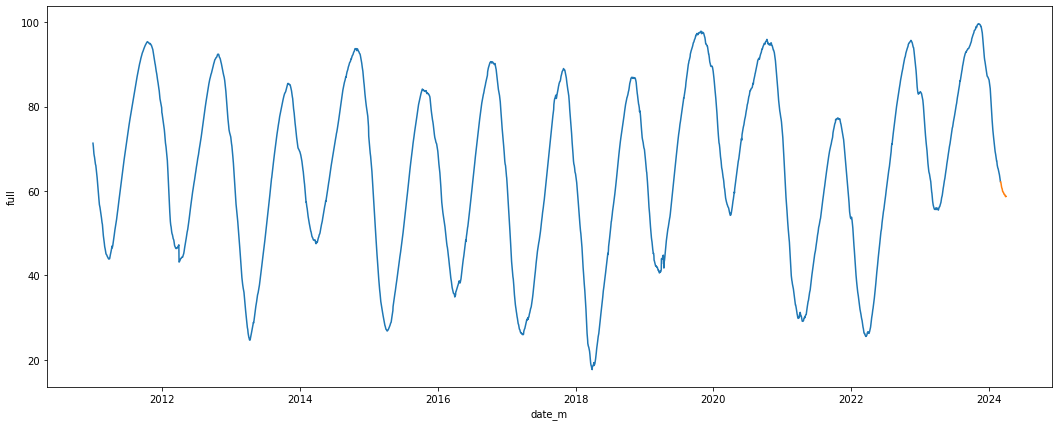

In [284]:
# print(train.shape)
fig = plt.figure(figsize=(18,7))
sns.lineplot(train[:]);
sns.lineplot(test[:]);
model = ARIMA(train,order=(5,1,5))
model = model.fit()
model.summary()

/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['type']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='date_m', ylabel='full'>

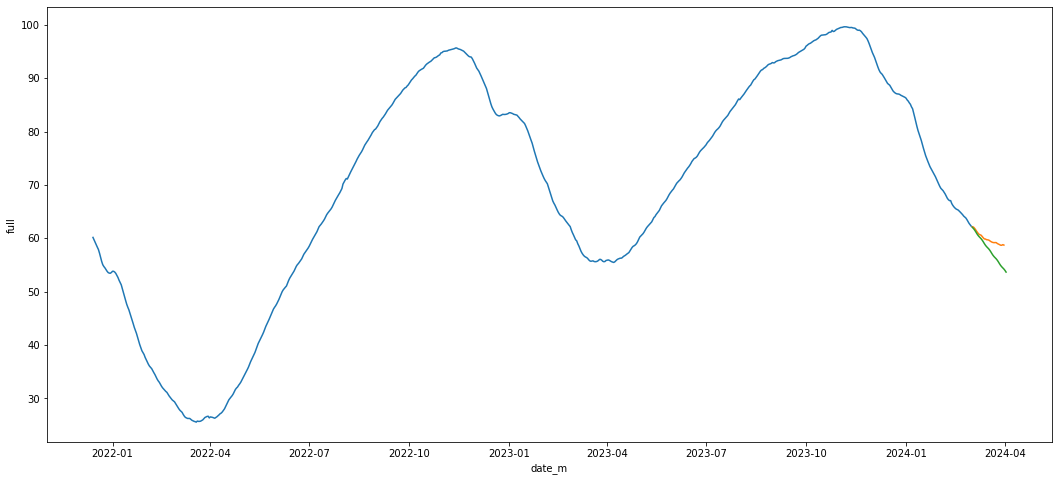

In [288]:
start = len(train)
end = start + len(test) + 1
pred = model.predict(start=start, end=end, type='levels')
fig = plt.figure(figsize=(18,8))
sns.lineplot(train[4000:])
sns.lineplot(test)
sns.lineplot(pred)
# pred

# Extraire la saisonnaité

In [302]:
from statsmodels.tsa.seasonal import seasonal_decompose

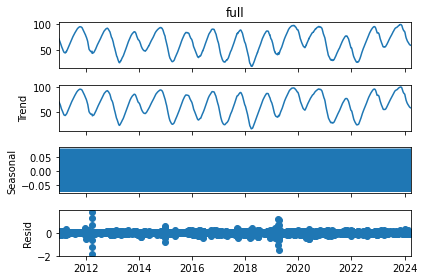

In [305]:
saison = seasonal_decompose(data['full'][::-1])
saison.plot();

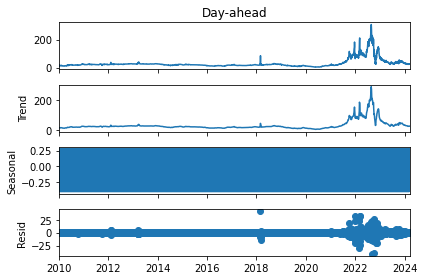

In [306]:
saison = seasonal_decompose(dataPrices['Day-ahead'])
saison.plot();